# Jordan Lake Spatiotemporal Simulation
ASV wind characterization simulation at the Jordan Lake mission domain.

Features:
- STGPKF Formulation
    - Generate Synthetic Data
    - Make estimates based upon existing measurements
- Ergodic Control
- Real-Time SOC-Based speed control
- Hyperparameter Estimation

In [1]:
# Import Packages
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

using LinearAlgebra
using Random
using Statistics
using Plots
using LaTeXStrings
using Revise
using StaticArrays
using Interpolations
using LazySets

In [2]:
# Import modules
include("../src/jordan_lake_domain.jl")
include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/Convex_bound_avoidance.jl")

Main.ConvexBoundAvoidance

# Generate Synthetic Data

In [9]:
# Define simulation time-scale/steps
Δt = 5.0 # seconds
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts = T_begin:dt_hrs:T_end # hours

9.0:0.001388888888888889:12.0

In [10]:
# Define environment hyperparameters
λₛ = 1/0.4; # spatial length scale [1/km]
λₜ = 1/3000; # temporal length scale [1/s]
σ = 0.5; # Standard Deviation

# Define covariance functions
kₛ(𝐬₁, 𝐬₂) = exp(-λₛ * norm(𝐬₁ - 𝐬₂));
kₜ(t₁, t₂) = σ^2 * exp(-λₜ * (t₁ - t₂));
k(𝐬₁, t₁, 𝐬₂, t₂) = kₛ(𝐬₁, 𝐬₂) * kₜ(t₁, t₂);

# Establish Jordan Lake Domain
domain = JordanLakeDomain.𝐬;
M = length(domain);

𝐊ₘ = reshape([kₛ(domain[j], domain[i]) for i = 1:M for j = 1:M], (M, M));

𝐊ₘʰᵃˡᶠ = cholesky(𝐊ₘ).L;
# 𝐊ₘʰᵃˡᶠ = sqrt(𝐊ₘ)

F = -λₜ;
G = 1;
H = σ * sqrt(2 * λₜ);
Σ₀ = 1 / (2 * λₜ);
𝐇ᵇᵃʳ = Diagonal(H * ones(M));

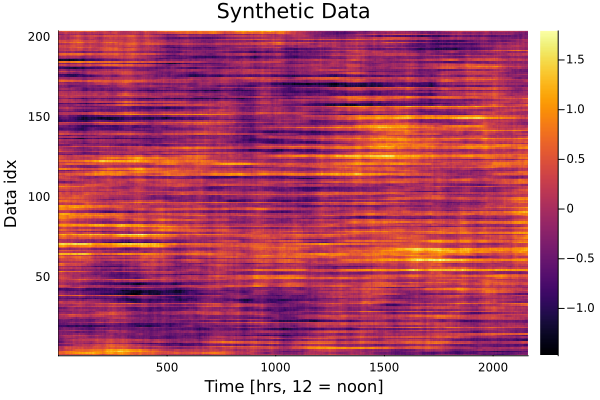

In [17]:
# Simulate env_data for all i ∈ {1, ..., T / Δt}
env_data = zeros(M, length(ts))

Random.seed!(3) # Set seed for reproducibility
𝐯ᵢ = sqrt(Σ₀) * randn(M)
for i = 1:length(ts)
    𝐰ᵢᵗⁱˡᵈᵉ = sqrt(1 / (2 * λₜ) * (1 - exp(-2 * λₜ * Δt))) * randn(M)
    𝐯ᵢ = exp(-λₜ * Δt) * 𝐯ᵢ + 𝐰ᵢᵗⁱˡᵈᵉ
    𝐳ᵢ = H * 𝐯ᵢ
    env_data[:, i] = 𝐊ₘʰᵃˡᶠ * 𝐳ᵢ
end
heatmap(env_data)
title!("Synthetic Data")
xlabel!("Time [hrs, 12 = noon]")
ylabel!("Data idx")

[ Info: Saved animation to /tmp/jl_NWbqhmx2NC.gif


Plots.AnimatedGif("/tmp/jl_NWbqhmx2NC.gif")
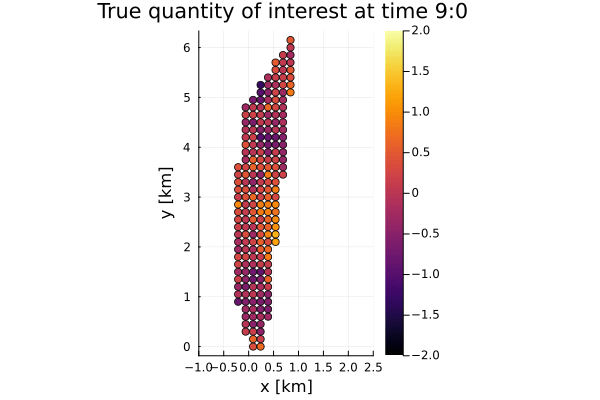

In [71]:
idx, idy = size(env_data)
windfield = @animate for time_idx in 1:100:idy
    scatter([x_y[1] for x_y in domain], [x_y[2] for x_y in domain], zcolor=env_data[:, time_idx],
    legend=false, colorbar=true, aspect_ratio=:equal, clims=(-2, 2));
    xlabel!("x [km]");
    xlims!(-1, 2.5);
    xticks!(-1:0.5:2.5);
    ylabel!("y [km]");
    title!("True quantity of interest at time $(Int(floor(ts[time_idx]))):$(Int(floor(mod(ts[time_idx],1)*60))) ")
end
gif(windfield)

# Known Hyperparameter Simulation

## Controller Setup

In [ ]:
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)
target_q_mat = ones(Nx, Ny)
target_q_mat *= 0.0

x_domain = range(0, 1.4, length=Nx)
y_domain = range(0, 6.5, length=Ny)

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if p ∈ convex_polygon.polygon
            target_q_mat[i, j] = 0.95
        end
    end
end

In [ ]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(ΔT)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

In [ ]:
using DifferentialEquations
using ForwardDiff

function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end

C = Cfun(0, 0)
R = Rfun(0, 0)
Q = 0.0
Clarity_decay(u,p,t) = (C^2 / R) * (1-u)^2 - Q * u^2
k = (C^2 / R)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end


function Forward_Simulate_Clarity(current_clarity, target_clarity; fn::Function = Clarity)
    """
    Forward simulate for maximum 10 seconds
    Here for now I only consider the spatiostatic environment 
    """    
    tspan = (0.0, 10.0) # 10 is just chosen to be a huge value for this problem
    u0 = current_clarity
    prob = ODEProblem(fn, u0, tspan)
    condition(u, t, integrator) = u ≥ target_clarity
    affect!(integrator) = terminate!(integrator)
    cb = DiscreteCallback(condition, affect!)
    sol = solve(prob, Tsit5(), callback = cb);
    return sol.t[end]
    
end

In [ ]:
using LinearAlgebra, StatsBase

function ergo_controller3(t, xs, convex_polygon; 
        ergo_grid,
        ergo_q_map,
        traj,
        umax= 30.0 * 60 / 1000, # 0.15
        ΔT,
        kwargs...
        )

    target_q = 0.9 ; # * ones(size(ergo_q_map))
    


    # Set the rated value matrix    
    Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)
    target_q_mat = ones(Nx, Ny)
    target_q_mat *= 0.0

    x_domain = range(0, 1.4, length=Nx)
    y_domain = range(0, 6.5, length=Ny)

    for i in 1:length(x_domain)
        for j in 1:length(y_domain)
            p = [x_domain[i], y_domain[j]]
            if p ∈ convex_polygon.polygon
                target_q_mat[i, j] = 0.95
            end
        end
    end

    # Get it in the right shape
    q_target_itp = linear_interpolation((ngpkf_grid.xs, ngpkf_grid.ys), target_q_mat, extrapolation_bc=Interpolations.Line())
    q_target_final = q_target_itp(ErgodicController.xs(ergo_grid), ErgodicController.ys(ergo_grid)) 
    
    target_spatial_dist = zeros(size(ergo_q_map))

    Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

    
    # Only explore the right-hand side of the environment
    for i in CartesianIndices(target_spatial_dist)
        if target_q > ergo_q_map[i]
            target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], q_target_final[i])
        else
            target_spatial_dist[i] = 0.0
        end
    end
    
    # Control input with convex boundary correction
    u = [ErgodicController.controller_single_integrator_cvx_bound(ergo_grid, x, traj, target_spatial_dist, convex_polygon; umax=umax, do_boundary_correction=true) for x in xs]
    
#     # Control input with rectangular boundary correction
#     u = [ErgodicController.controller_single_integrator(ergo_grid, x, traj, target_spatial_dist; umax=umax, do_boundary_correction=false) for x in xs]
    return u

end

ergo_controllers3 = [ergo_controller3 for i=1:length(x0s)]

## Generate SOC Target Profile

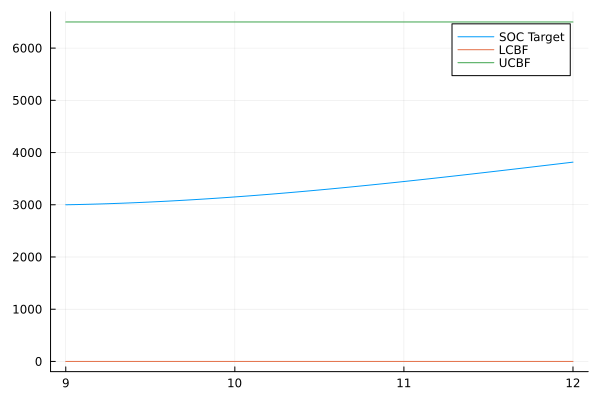

In [ ]:
# Generate SOC_Target Profile
soc_begin = 3000
soc_end = 3500
lcbf = SoCController.compute_lcbf(ts, dt_hrs);
ucbf = SoCController.compute_ucbf(ts, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts, dt_hrs);
plot(ts, soc_target, label="SOC Target")
plot!(ts, lcbf, label="LCBF")
plot!(ts,ucbf, label="UCBF")

## Simulate

In [ ]:
fuse_measurements_every_ΔT = 5.0 # minutes
recompute_controller_every_ΔT = 5.0 / 120.0 # minutes
σ_t = zeros(15, 66);

@time res_ergo_hp =  SimulatorST.simulate_known_param(ts, x0s, soc_begin, ergo_controller3, soc_target, convex_polygon; 
    ngpkf_grid=ngpkf_grid, 
    EnvDataSpatial=env_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)